## **Подготовка окружения**

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство для вычислений: cuda


## **Физические параметры и аналитическое решение**

In [ ]:
# Параметры RLC-контура
R = 0.4       # Сопротивление, Ом
L = 1.0       # Индуктивность, Гн
C = 0.1       # Емкость, Ф
Q0 = 1.0      # Начальный заряд, Кл
I0 = 0.0      # Начальный ток, А

# Коэффициенты затухающих колебаний
gamma = R / (2 * L)
omega_0_sq = 1 / (L * C)
omega_d = np.sqrt(omega_0_sq - gamma**2)
print(f"gamma = {gamma}, omega_d = {omega_d:.4f}")

def exact_solution(t):
    """Аналитическое решение для заряда в RLC-контуре"""
    return Q0 * np.exp(-gamma * t) * (np.cos(omega_d * t) + (gamma / omega_d) * np.sin(omega_d * t))

Физические параметры контура: gamma = 0.2, omega_d = 3.1559


## **Архитектура нейронной сети и три различных анзаца**

In [ ]:
class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)

In [ ]:
class PINN_Ansatz1(nn.Module):
    """Гибридный анзац: точное решение + корректировка от сети"""
    def __init__(self, t_physics_max=9.0):
        super().__init__()
        self.t_max = t_physics_max
        self.net = nn.Sequential(
            nn.Linear(1, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.uniform_(m.weight, -1e-2, 1e-2)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        t_norm = t / self.t_max
        
        # Точное аналитическое решение в тензорном виде
        decay = torch.exp(-gamma * t)
        harmonic = torch.cos(omega_d * t) + (gamma / omega_d) * torch.sin(omega_d * t)
        base = Q0 * decay * harmonic
        
        # Поправка: t² * exp(-γt) * сеть(t)
        # Обеспечивает q(0) = Q0 и q'(0) = 0
        correction = (t ** 2) * decay * self.net(t_norm)
        return base + correction

In [ ]:
class PINN_Ansatz2(nn.Module):
    """Простой экспоненциальный анзац: сеть восстанавливает колебания с нуля"""
    def __init__(self, t_physics_max=9.0):
        super().__init__()
        self.t_max = t_physics_max
        self.net = nn.Sequential(
            nn.Linear(1, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.uniform_(m.weight, -1e-2, 1e-2)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        t_norm = t / self.t_max
        output = self.net(t_norm)
        
        # q(t) = Q0 * exp(-γt) + (1 - exp(-t²)) * exp(-γt) * сеть(t)
        # Гарантирует q(0) = Q0, q'(0) = 0
        decay = torch.exp(-gamma * t)
        q_pred = Q0 * decay + (1.0 - torch.exp(-t**2)) * decay * output
        return q_pred

In [ ]:
class PINN_Ansatz3(nn.Module):
    """Параметрический анзац: сеть предсказывает амплитуду и фазу"""
    def __init__(self, t_physics_max=9.0):
        super().__init__()
        self.t_max = t_physics_max
        self.net = nn.Sequential(
            nn.Linear(1, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 128), Sine(),
            nn.Linear(128, 2)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.uniform_(m.weight, -1e-2, 1e-2)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        t_norm = t / self.t_max
        params = self.net(t_norm)
        
        # Сеть выдает модуляцию амплитуды и фазовый сдвиг
        A_pred = params[:, 0:1]
        phi_pred = params[:, 1:2]

        # q(t) = Q0 * exp(-γt) * (1 + (1 - exp(-t²)) * A * cos(ωt + φ))
        decay = torch.exp(-gamma * t)
        harmonic = torch.cos(omega_d * t + phi_pred)
        q_pred = Q0 * decay * (1.0 + (1.0 - torch.exp(-t**2)) * A_pred * harmonic)
        return q_pred

## **Вычисление производных**

In [ ]:
def compute_derivatives(q, t):
    """Вычисляет dq/dt и d²q/dt² через автоматическое дифференцирование"""
    dq_dt = torch.autograd.grad(
        outputs=q,
        inputs=t,
        grad_outputs=torch.ones_like(q),
        create_graph=True,
        retain_graph=True
    )[0]

    d2q_dt2 = torch.autograd.grad(
        outputs=dq_dt,
        inputs=t,
        grad_outputs=torch.ones_like(dq_dt),
        create_graph=True,
        retain_graph=True
    )[0]

    return dq_dt, d2q_dt2

## **Подготовка данных**

In [ ]:
t_max = 6.0
t_physics_max = 9.0

# Сетка для оценки метрик интерполяции (до 6 сек)
t_test_np = np.linspace(0, t_max, 500)
q_test_exact = exact_solution(t_test_np).flatten()

# Расширенная сетка для графиков (до 9 сек)
t_test_full = np.linspace(0, t_physics_max, 750)
q_exact_full = exact_solution(t_test_full)
i_exact_full = -gamma * q_exact_full + Q0 * np.exp(-gamma * t_test_full) * (-omega_d * np.sin(omega_d * t_test_full) + gamma * np.cos(omega_d * t_test_full))

train_mask = t_test_full <= t_max
extrap_mask = t_test_full > t_max

# Словарь для результатов всех трех анзацев
all_experiments_results = {}

# Тренировочные точки для PDE loss
t_train = torch.linspace(0, t_physics_max, 2000).view(-1, 1).to(device).requires_grad_(True)
t_val = (torch.rand(500, 1) * t_physics_max).to(device).requires_grad_(True)

# Точки с известными данными (data loss)
n_data = 50
t_data = (torch.rand(n_data, 1) * t_physics_max).to(device)
q_data = torch.tensor(exact_solution(t_data.cpu().numpy()), dtype=torch.float32, device=device).reshape(-1,1)

## **Обучение моделей**

In [ ]:
ansatz_classes = {
    1: ("Анзац 1: Гибридный", PINN_Ansatz1),
    2: ("Анзац 2: Экспоненциальный", PINN_Ansatz2),
    3: ("Анзац 3: Параметрический", PINN_Ansatz3)
}

log_filename = "training_log.txt"

def log_and_print(message):
    """Выводит в консоль и дописывает в лог"""
    print(message)
    with open(log_filename, "a", encoding="utf-8") as f:
        f.write(message + "\n")

# Очищаем лог перед началом
with open(log_filename, "w", encoding="utf-8") as f:
    f.write("=== ЛОГ ОБУЧЕНИЯ МОДЕЛЕЙ PINN ===\n\n")

trained_pinn_models = {}

for name_idx, (name, ModelClass) in ansatz_classes.items():
    log_and_print("\n" + "="*60)
    log_and_print(f" Обучение: {name}")
    log_and_print("="*60)
    
    model = ModelClass(t_physics_max=t_physics_max).to(device)
    
    history = {'epoch': [], 'train_phys_loss': [], 'val_phys_loss': [], 'test_rmse': []}
    loss_history_total = []
    
    def get_physics_residual(t):
        """Остаток уравнения: L*q'' + R*q' + (1/C)*q = 0"""
        q = model(t)
        dq_dt, d2q_dt2 = compute_derivatives(q, t)
        return L * d2q_dt2 + R * dq_dt + (1.0 / C) * q

    def record_metrics(current_step):
        model.eval()
        with torch.no_grad():
            t_test_tensor_internal = torch.tensor(t_test_np, dtype=torch.float32).view(-1, 1).to(device)
            q_pred_test = model(t_test_tensor_internal).cpu().numpy().flatten()
        model.train()

        loss_p_train = torch.mean(get_physics_residual(t_train) ** 2).item()
        loss_p_val = torch.mean(get_physics_residual(t_val) ** 2).item()
        rmse = np.sqrt(np.mean((q_pred_test - q_test_exact) ** 2))

        history['epoch'].append(current_step)
        history['train_phys_loss'].append(loss_p_train)
        history['val_phys_loss'].append(loss_p_val)
        history['test_rmse'].append(rmse)
        return loss_p_train, loss_p_val, rmse

    # Этап 1: Adam
    adam_epochs = 2000
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=0.002)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, patience=500, factor=0.5)

    log_and_print(">>> Этап 1: Adam оптимизация...")
    for epoch in range(1, adam_epochs + 1):
        optimizer_adam.zero_grad()
        loss_phys = torch.mean(get_physics_residual(t_train) ** 2)
        q_pred_data = model(t_data)
        loss_data = torch.mean((q_pred_data - q_data) ** 2)
        loss_total = loss_phys + 10.0 * loss_data
        loss_total.backward()
        optimizer_adam.step()
        scheduler.step(loss_total)

        loss_history_total.append(loss_total.item())

        if epoch % 100 == 0 or epoch == 1:
            lp_train, lp_val, test_rmse = record_metrics(epoch)
            log_and_print(f"Эпоха: {epoch:4d} | Train Loss: {lp_train:.6f} | Val Loss: {lp_val:.6f} | RMSE: {test_rmse:.6e}")

    # Этап 2: L-BFGS полировка
    lbfgs_iters = 2000
    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=lbfgs_iters, 
                                        history_size=100, line_search_fn="strong_wolfe")

    log_and_print("\n>>> Этап 2: L-BFGS полировка...")
    iter_tracker = [0]

    def closure():
        optimizer_lbfgs.zero_grad()
        loss_phys = torch.mean(get_physics_residual(t_train) ** 2)
        q_pred_data = model(t_data)
        loss_data = torch.mean((q_pred_data - q_data) ** 2)
        loss_total = loss_phys + 10.0 * loss_data
        loss_total.backward()

        loss_history_total.append(loss_total.item())

        if iter_tracker[0] % 10 == 0:
            lp_train, lp_val, test_rmse = record_metrics(adam_epochs + iter_tracker[0])
            log_and_print(f"L-BFGS: {iter_tracker[0]:3d} | Train Loss: {lp_train:.6f} | RMSE: {test_rmse:.6e}")

        iter_tracker[0] += 1
        return loss_total

    optimizer_lbfgs.step(closure)
    log_and_print(f"Обучение {name} завершено!\n")

    trained_pinn_models[name_idx] = {
        'model_object': model,
        'loss_history_total': list(loss_history_total),
        'last_phys_loss': history['train_phys_loss'][-1] if len(history['train_phys_loss']) > 0 else 0.0
    }


 СТАРТ: Обучение модели — Анзац 1: Детерминированный
>>> Запуск ЭТАПА 1: Оптимизация через Adam...


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Эпоха:    1 | Train Phys Loss: 0.085232 | Val Phys Loss: 0.079384 | Test RMSE: 2.039529e-02
Эпоха:  100 | Train Phys Loss: 0.000000 | Val Phys Loss: 0.000000 | Test RMSE: 1.110441e-05
Эпоха:  200 | Train Phys Loss: 0.000000 | Val Phys Loss: 0.000000 | Test RMSE: 2.905191e-06
Эпоха:  300 | Train Phys Loss: 0.000000 | Val Phys Loss: 0.000000 | Test RMSE: 2.437060e-06
Эпоха:  400 | Train Phys Loss: 0.000000 | Val Phys Loss: 0.000000 | Test RMSE: 1.960481e-06
Эпоха:  500 | Train Phys Loss: 0.000000 | Val Phys Loss: 0.000000 | Test RMSE: 1.526265e-06
Эпоха:  600 | Train Phys Loss: 0.000000 | Val Phys Loss: 0.000000 | Test RMSE: 1.323620e-06
Эпоха:  700 | Train Phys Loss: 0.000000 | Val Phys Loss: 0.000000 | Test RMSE: 1.135234e-06
Эпоха:  800 | Train Phys Loss: 0.000000 | Val Phys Loss: 0.000000 | Test RMSE: 9.585971e-07
Эпоха:  900 | Train Phys Loss: 0.000000 | Val Phys Loss: 0.000000 | Test RMSE: 7.974464e-07
Эпоха: 1000 | Train Phys Loss: 0.000000 | Val Phys Loss: 0.000000 | Test RMSE: 6

## **Итоговые метрики**

In [ ]:
all_experiments_results = {}

t_extrap_max = 9.0
t_test_full_local = np.linspace(0, t_extrap_max, 750)

for idx, saved_data in trained_pinn_models.items():
    model = saved_data['model_object']
    model.eval()
    
    # Полная сетка для графиков
    t_test_tensor_full = torch.tensor(t_test_full_local, dtype=torch.float32).view(-1, 1).requires_grad_(True).to(device)
    q_pinn_tensor = model(t_test_tensor_full)
    i_pinn_tensor, d2q_dt2_pinn_tensor = compute_derivatives(q_pinn_tensor, t_test_tensor_full)

    q_pinn = q_pinn_tensor.detach().cpu().numpy().flatten()
    i_pinn = i_pinn_tensor.detach().cpu().numpy().flatten()
    residual_test = (L * d2q_dt2_pinn_tensor + R * i_pinn_tensor + (1/C) * q_pinn_tensor).detach().cpu().numpy().flatten()

    # Метрики на базовой сетке (интерполяция)
    with torch.no_grad():
        t_test_tensor_base = torch.tensor(t_test_np, dtype=torch.float32).view(-1, 1).to(device)
        q_final_pred_base = model(t_test_tensor_base).cpu().numpy().flatten()
        
    final_rmse = np.sqrt(np.mean((q_final_pred_base - q_test_exact) ** 2))
    final_mae = np.mean(np.abs(q_final_pred_base - q_test_exact))
    max_error = np.max(np.abs(q_final_pred_base - q_test_exact))
    relative_l2 = np.linalg.norm(q_final_pred_base - q_test_exact) / np.linalg.norm(q_test_exact)
    final_msr = saved_data['last_phys_loss']

    all_experiments_results[idx] = {
        'q_pinn': q_pinn,
        'i_pinn': i_pinn,
        'residual_test': residual_test,
        'loss_history_total': saved_data['loss_history_total'],
        'metrics': {
            'relative_l2': relative_l2, 'max_error': max_error,
            'rmse': final_rmse, 'mae': final_mae, 'msr': final_msr
        }
    }

# Таблица результатов
log_and_print("\n" + "="*85)
log_and_print(f"{'Модель':<25} | {'Relative L2':<12} | {'Max Error':<12} | {'RMSE':<12} | {'MSR':<12}")
log_and_print("="*85)
for idx, data in sorted(all_experiments_results.items()):
    m = data['metrics']
    log_and_print(f"Анзац №{idx:<18} | {m['relative_l2']:.6f} | {m['max_error']:.6f} | {m['rmse']:.6f} | {m['msr']:.6f}")
log_and_print("="*85 + "\n")


Модель (Анзац)            | Relative L2  | Max Error    | RMSE         | MSR (Phys)  
Анзац №1                  | 0.000001 | 0.000001 | 0.000000 | 0.000000
Анзац №2                  | 0.884106 | 0.787116 | 0.388781 | 1.628844
Анзац №3                  | 0.090170 | 0.088555 | 0.039652 | 0.030979



## **Визуализация результатов**

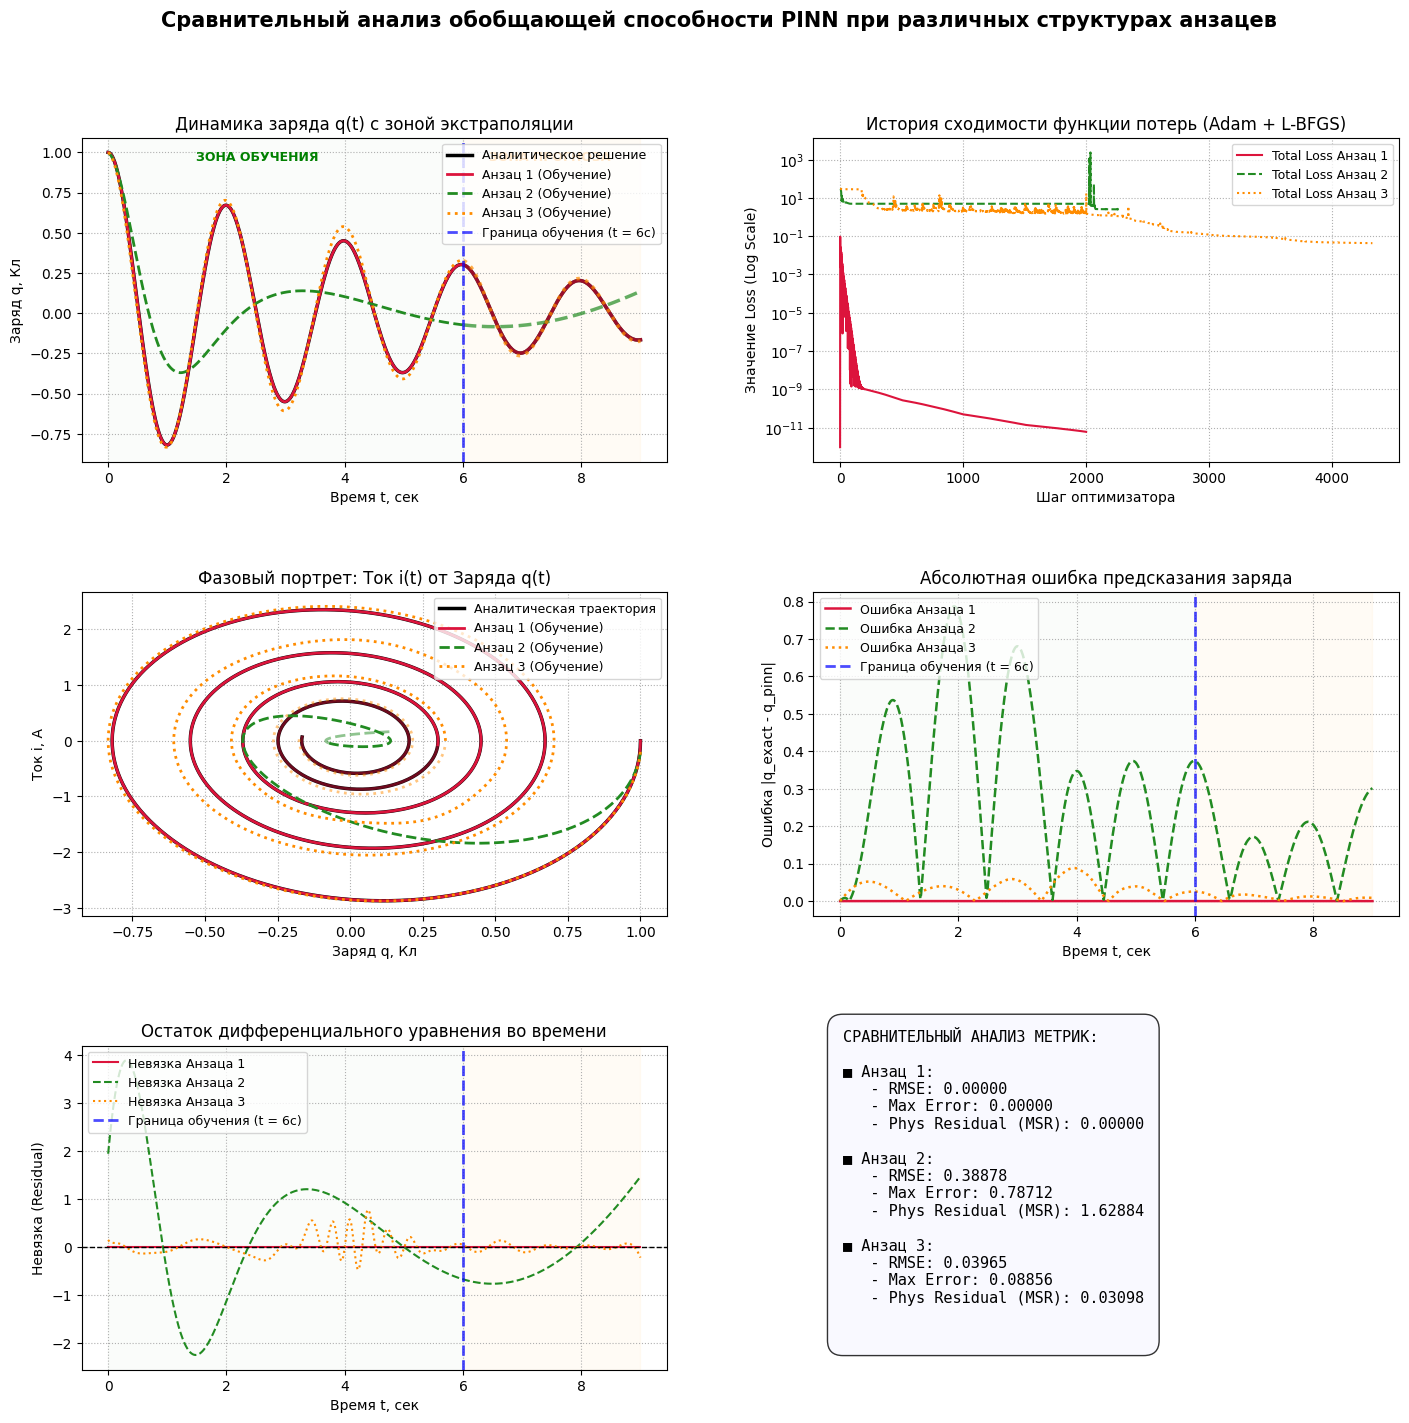

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(17, 16))
plt.subplots_adjust(hspace=0.4, wspace=0.25)

def highlight_zones(ax):
    ax.axvline(t_max, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='Граница обучения (t = 6с)')
    ax.axvspan(0, t_max, color='green', alpha=0.02)
    ax.axvspan(t_max, t_extrap_max, color='orange', alpha=0.04)

colors = {1: 'crimson', 2: 'forestgreen', 3: 'darkorange'}
styles = {1: '-', 2: '--', 3: ':'}

# Динамика заряда
axs[0, 0].plot(t_test_full, q_exact_full, label='Аналитическое решение', color='black', linewidth=2.5)
for idx, res in sorted(all_experiments_results.items()):
    axs[0, 0].plot(t_test_full[train_mask], res['q_pinn'][train_mask], linestyle=styles[idx], color=colors[idx], linewidth=2, label=f'Анзац {idx} (Обучение)')
    axs[0, 0].plot(t_test_full[extrap_mask], res['q_pinn'][extrap_mask], linestyle=styles[idx], color=colors[idx], linewidth=2.5, alpha=0.7)
highlight_zones(axs[0, 0])
axs[0, 0].set_title('Динамика заряда q(t)')
axs[0, 0].set_xlabel('Время, сек')
axs[0, 0].set_ylabel('Заряд, Кл')
axs[0, 0].grid(True, linestyle=':')
axs[0, 0].legend(loc='upper right', fontsize=9)
axs[0, 0].text(0.3, 0.93, 'ОБУЧЕНИЕ', transform=axs[0, 0].transAxes, color='green', fontweight='bold', ha='center', fontsize=9)
axs[0, 0].text(0.8, 0.93, 'ПРОГНОЗ', transform=axs[0, 0].transAxes, color='darkorange', fontweight='bold', ha='center', fontsize=9)

# История обучения
for idx, res in sorted(all_experiments_results.items()):
    axs[0, 1].plot(res['loss_history_total'], color=colors[idx], linestyle=styles[idx], linewidth=1.5, label=f'Анзац {idx}')
axs[0, 1].set_yscale('log')
axs[0, 1].set_title('История сходимости')
axs[0, 1].set_xlabel('Шаг оптимизации')
axs[0, 1].set_ylabel('Loss (log шкала)')
axs[0, 1].grid(True, linestyle=':')
axs[0, 1].legend(fontsize=9)

# Фазовый портрет
axs[1, 0].plot(q_exact_full, i_exact_full, label='Аналитическая траектория', color='black', linewidth=2.5)
for idx, res in sorted(all_experiments_results.items()):
    axs[1, 0].plot(res['q_pinn'][train_mask], res['i_pinn'][train_mask], linestyle=styles[idx], color=colors[idx], linewidth=2, label=f'Анзац {idx} (Обучение)')
    axs[1, 0].plot(res['q_pinn'][extrap_mask], res['i_pinn'][extrap_mask], linestyle=styles[idx], color=colors[idx], linewidth=2, alpha=0.5)
axs[1, 0].set_title('Фазовый портрет i(q)')
axs[1, 0].set_xlabel('Заряд q, Кл')
axs[1, 0].set_ylabel('Ток i, А')
axs[1, 0].grid(True, linestyle=':')
axs[1, 0].legend(fontsize=9)

# Абсолютная ошибка
for idx, res in sorted(all_experiments_results.items()):
    abs_err = np.abs(q_exact_full - res['q_pinn'])
    axs[1, 1].plot(t_test_full, abs_err, color=colors[idx], linestyle=styles[idx], linewidth=1.8, label=f'Ошибка {idx}')
highlight_zones(axs[1, 1])
axs[1, 1].set_title('Абсолютная ошибка предсказания')
axs[1, 1].set_xlabel('Время, сек')
axs[1, 1].set_ylabel('Ошибка')
axs[1, 1].grid(True, linestyle=':')
axs[1, 1].legend(loc='upper left', fontsize=9)

# Остаток уравнения
for idx, res in sorted(all_experiments_results.items()):
    axs[2, 0].plot(t_test_full, res['residual_test'], color=colors[idx], linestyle=styles[idx], linewidth=1.5, label=f'Невязка {idx}')
highlight_zones(axs[2, 0])
axs[2, 0].set_title('Остаток дифференциального уравнения')
axs[2, 0].set_xlabel('Время, сек')
axs[2, 0].set_ylabel('Residual')
axs[2, 0].grid(True, linestyle=':')
axs[2, 0].axhline(0, color='black', linewidth=1, linestyle='--')
axs[2, 0].legend(loc='upper left', fontsize=9)

# Сравнительная таблица метрик
axs[2, 1].axis('off')
text_data = "СРАВНЕНИЕ МЕТРИК:\n\n"
for idx, data in sorted(all_experiments_results.items()):
    m = data['metrics']
    text_data += f"■ Анзац {idx}:\n"
    text_data += f"   RMSE: {m['rmse']:.5f}\n"
    text_data += f"   Max Error: {m['max_error']:.5f}\n"
    text_data += f"   Residual: {m['msr']:.5f}\n\n"
axs[2, 1].text(0.05, 0.1, text_data, fontsize=11, family='monospace', bbox=dict(facecolor='ghostwhite', alpha=0.8, boxstyle='round,pad=1'))

plt.suptitle('Сравнение трех структур анзацев PINN', fontsize=15, fontweight='bold', y=0.96)
plt.show()